# Notebook 07 : Synthèse et comparaison finale

**Objectif** : Rassembler les résultats des 3 modèles, produire les figures 
et tableaux de comparaison finaux.

imports + rechargement des données + ré-entraînement des 3 modèles

## 0. Imports, rechargement des données et ré-entraînement des 3 modèles

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
from sklearn.metrics import roc_auc_score, roc_curve

plt.style.use('seaborn-v0_8-darkgrid')

# Chargement des données
X_train = pd.read_csv("../data/processed/X_train.csv")
X_test = pd.read_csv("../data/processed/X_test.csv")
y_train = pd.read_csv("../data/processed/y_train.csv").squeeze()
y_test = pd.read_csv("../data/processed/y_test.csv").squeeze()

ratio = (y_train == 0).sum() / (y_train == 1).sum()

# Ré-entraînement des 3 modèles
print("Entraînement régression logistique...")
model_lr = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
model_lr.fit(X_train, y_train)

print("Entraînement Random Forest...")
model_rf = RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42, n_jobs=-1)
model_rf.fit(X_train, y_train)

print("Entraînement XGBoost...")
model_xgb = xgb.XGBClassifier(max_depth=4, learning_rate=0.1, n_estimators=300,
                                scale_pos_weight=ratio, random_state=42, n_jobs=-1, eval_metric='auc')
model_xgb.fit(X_train, y_train)

Entraînement régression logistique...
Entraînement Random Forest...
Entraînement XGBoost...


,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'auc'
,feature_types feature_types: typing.Sequence[str] | None.. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


## 1. Calcul des métriques et courbes ROC superposées

COMPARAISON FINALE DES 3 MODÈLES
Modèle                              AUC     Gini       KS
------------------------------------------------------------
Régression logistique            0.7485   0.4970   0.3703
Random Forest                    0.7390   0.4779   0.3546
XGBoost (optimisé)               0.7589   0.5179   0.3836


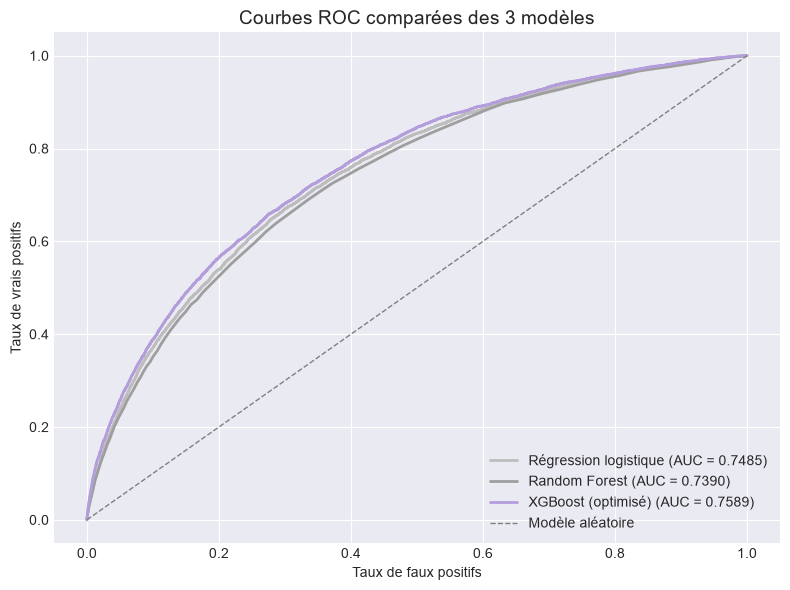

In [3]:
# Prédictions
y_proba_lr = model_lr.predict_proba(X_test)[:, 1]
y_proba_rf = model_rf.predict_proba(X_test)[:, 1]
y_proba_xgb = model_xgb.predict_proba(X_test)[:, 1]

# Métriques
modeles = {
    'Régression logistique': y_proba_lr,
    'Random Forest': y_proba_rf,
    'XGBoost (optimisé)': y_proba_xgb
}


print("COMPARAISON FINALE DES 3 MODÈLES")
print(f"{'Modèle':<30} {'AUC':>8} {'Gini':>8} {'KS':>8}")
print("-" * 60)

courbes = {}
for nom, y_proba in modeles.items():
    auc = roc_auc_score(y_test, y_proba)
    gini = 2 * auc - 1
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    ks = max(tpr - fpr)
    courbes[nom] = (fpr, tpr, auc)
    print(f"{nom:<30} {auc:>8.4f} {gini:>8.4f} {ks:>8.4f}")

# Courbes ROC superposées
fig, ax = plt.subplots(figsize=(8, 6))

couleurs = {'Régression logistique': '#BDBDBD', 'Random Forest': '#9E9E9E', 'XGBoost (optimisé)': '#B39DDB'}

for nom, (fpr, tpr, auc) in courbes.items():
    ax.plot(fpr, tpr, color=couleurs[nom], linewidth=2, label=f'{nom} (AUC = {auc:.4f})')

ax.plot([0, 1], [0, 1], color='gray', linestyle='--', linewidth=1, label='Modèle aléatoire')
ax.set_title("Courbes ROC comparées des 3 modèles", fontsize=14)
ax.set_xlabel("Taux de faux positifs")
ax.set_ylabel("Taux de vrais positifs")
ax.legend(loc='lower right')

plt.tight_layout()
plt.savefig("../outputs/figures/18_roc_comparaison_3_modeles.png", dpi=150, bbox_inches='tight')
plt.show()

XGBoost (violet) est légèrement au-dessus, la logistique et le RF quasi superposés en gris.

## Synthèse finale

### Classement des 3 modèles

1. **XGBoost (optimisé)** : AUC 0.7589, Gini 0.5179, KS 0.3836
2. **Régression logistique** : AUC 0.7485, Gini 0.4970, KS 0.3703
3. **Random Forest** : AUC 0.7390, Gini 0.4779, KS 0.3546

### Constats principaux

Le gain de XGBoost par rapport à la régression logistique est de **+1.04 point 
d'AUC**. C'est un gain réel, cohérent avec la littérature (Lessmann et al., 2015), 
mais modeste. En scoring de crédit, ce type d'écart se traduit par quelques 
centaines de décisions mieux classées sur un portefeuille de 100 000 clients.

Le Random Forest fait moins bien que la régression logistique (-0.95 point d'AUC). 
Un modèle plus complexe ne garantit pas un gain de performance.

### L'arbitrage central du mémoire

Le gain de +1.04 point d'AUC de XGBoost justifie-t-il son adoption au regard :
- De la perte d'interprétabilité native (coefficients lisibles vs boîte noire)
- Du surcoût de gouvernance (model risk management renforcé)
- Des exigences réglementaires (RGPD art. 22, AI Act, orientations EBA)

L'analyse SHAP (Notebook 06) a montré que :
- Les explications globales sont cohérentes avec l'intuition métier
- Les décisions extrêmes sont bien explicables
- Les cas ambigus révèlent une incertitude que SHAP rend transparente
- Mais SHAP reste une approximation post-hoc, pas une interprétabilité native

La réponse ne peut pas être binaire. Elle dépend du contexte, 
pour un portefeuille à haut volume où chaque point d'AUC représente des millions 
d'euros, le surcoût de gouvernance peut se justifier. Pour un portefeuille plus 
petit, la régression logistique reste un choix rationnel et conforme.